# 24-Hour Session Liquidity & Volatility Heatmap
*(Robust P10-P85 Percentile Normalization — outliers clipped, trading hours readable)*

### Key Features
1. **Per-Symbol Robust Normalization (P10-P85):** Each row is scaled independently. Outlier rollover spikes saturate at 1.0 without crushing the color range of normal trading hours.
2. **Zero-Value Masking:** Market-closed or zero-spread hours are shaded in **dark grey (#2A2A2A)** with muted text, preventing false "brightest/tightest" highlight.
3. **Dynamic Text Contrast:** Text color (black vs. white) is calculated automatically from the cell's RGB luminance for 100% legibility across all colormaps.

### Three Heatmaps
1. **Spread** `YlOrRd` — yellow = tightest, red = widest
2. **Volatility** `viridis` — dark = calm, bright = active  
3. **Efficiency** `RdYlGn` — green = best hours (high vol / low spread)

### Sessions (UTC)
| Session | Hours |
|---|---|
| Asian | 00-08 |
| London | 08-16 |
| **London/NY Overlap** | **13-16** |
| New York | 13-21 |
| **Rollover** | **23-01** |


In [24]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from datetime import datetime, timedelta, UTC

plt.style.use('dark_background')
print("Imports OK")


Imports OK


In [25]:
if not mt5.initialize():
    raise RuntimeError(f"MT5 init failed: {mt5.last_error()}")
info = mt5.terminal_info()
print(f"Connected: {info.name} ({info.company}) | Build {mt5.version()[1]}")


Connected: RoboForex MT5 Terminal (RoboForex Ltd) | Build 6061


In [26]:
SYMBOLS     = ["EURUSD", "GBPUSD", "USDJPY", "WTI", "XAUUSD", ".US500Cash"]
HOUR_LABELS = [f"{h:02d}:00" for h in range(24)]
SESSION_BANDS = [
    (0,  8,  "Asian",    "#00E676"),
    (8,  16, "London",   "#00B0FF"),
    (13, 21, "New York", "#FF9100"),
    (23, 24, "Rollover", "#FF1744"),
]
print(f"Symbols: {SYMBOLS}")


Symbols: ['EURUSD', 'GBPUSD', 'USDJPY', 'WTI', 'XAUUSD', '.US500Cash']


In [27]:
def get_last_valid_trading_day():
    """Return (date_from, date_to) for the most recent complete weekday."""
    now = datetime.now()
    day = now.date()
    for _ in range(7):
        if day.weekday() < 5:
            break
        day -= timedelta(days=1)
    if day == now.date() and now.hour < 3:
        day -= timedelta(days=1)
        while day.weekday() >= 5:
            day -= timedelta(days=1)
    return (
        datetime.combine(day, datetime.min.time(), tzinfo=UTC),
        datetime.combine(day, datetime.max.time().replace(microsecond=0), tzinfo=UTC),
    )

def row_normalize_robust(data, lo_pct=10, hi_pct=85):
    """
    Per-row normalization with percentile clipping.
    Each row (symbol) is scaled independently so 0=tightest, 1=widest for THAT symbol.
    """
    normed = np.zeros_like(data, dtype=float)
    for i in range(data.shape[0]):
        row     = data[i]
        nonzero = row[row > 0]
        if len(nonzero) == 0:
            continue
        lo      = np.percentile(nonzero, lo_pct)
        hi      = np.percentile(row,     hi_pct)
        clipped = np.clip(row, lo, hi)
        span    = clipped.max() - clipped.min()
        normed[i] = (clipped - clipped.min()) / span if span > 0 else 0.5
    return normed

def add_session_bands(ax):
    for start, end, label, color in SESSION_BANDS:
        rect = Rectangle((start - 0.5, -0.75), end - start, 0.22,
                          facecolor=color, alpha=0.85, clip_on=False)
        ax.add_patch(rect)
        ax.text((start + end) / 2 - 0.5, -0.64, label,
                ha="center", va="center", color="black",
                fontsize=7.5, fontweight="bold", clip_on=False)

def draw_heatmap(raw, norm, syms, cmap_name, cbar_lo, cbar_hi, title, fmt_fn, overlap=False):
    n = len(syms)
    fig, ax = plt.subplots(figsize=(18, max(5, n * 1.3)), dpi=150)

    # 1. Colormap with dark grey for 0 / market closed cells
    cmap = plt.colormaps.get_cmap(cmap_name).copy()
    cmap.set_bad(color='#2A2A2A')

    # 2. Mask 0 or negative raw values
    norm_masked = np.ma.masked_where(raw <= 0, norm)

    im = ax.imshow(norm_masked, cmap=cmap, aspect="auto", vmin=0, vmax=1)

    cbar = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.025)
    cbar.set_ticks([0, 0.5, 1.0])
    cbar.set_ticklabels([cbar_lo, "Mid (per sym)", cbar_hi],
                        color="#CCCCCC", fontsize=8)
    cbar.set_label("Relative scale — per-symbol, P10-P85 clipping",
                   rotation=270, labelpad=20, color="#CCCCCC", fontsize=8)

    ax.set_xticks(range(24))
    ax.set_xticklabels(HOUR_LABELS, rotation=45, ha="right", fontsize=9, color="#CCCCCC")
    ax.set_yticks(range(n))
    ax.set_yticklabels(syms, fontsize=11, fontweight="bold", color="#E0E0E0")

    # 3. Dynamic luminance text contrast calculation
    for i in range(n):
        for j in range(24):
            val = raw[i, j]
            if val <= 0:
                txt = "0.00"
                tc  = "#666666"
            else:
                txt = fmt_fn(val)
                # Compute RGB luminance of cell background
                r, g, b, _ = cmap(norm[i, j])
                lum = 0.299 * r + 0.587 * g + 0.114 * b
                tc  = "black" if lum > 0.45 else "white"
            ax.text(j, i, txt, ha="center", va="center", color=tc, fontsize=7.5, fontweight="bold" if tc=="black" else "normal")

    ax.set_title(title, fontsize=13, pad=28, fontweight="bold", color="#E0E0E0")
    ax.set_xlabel("Hour of Day (UTC)", fontsize=11, labelpad=10, color="#CCCCCC")
    add_session_bands(ax)

    if overlap:
        ax.axvspan(12.5, 16.5, color="#FFEA00", alpha=0.07, zorder=0)
        ax.text(14.5, -1.25, "Peak Overlap (London+NY)",
                ha="center", va="center", color="#FFEA00",
                fontsize=8, fontweight="bold", clip_on=False)
    plt.tight_layout()
    plt.show()

print("Helper functions defined.")


Helper functions defined.


In [28]:
unit_map = {}

def build_24h_matrices(symbols):
    date_from, date_to = get_last_valid_trading_day()
    print(f"Target day: {date_from.strftime('%Y-%m-%d')}")
    sp, vol, vm = {}, {}, {}

    for sym in symbols:
        info = mt5.symbol_info(sym)
        if info is None:
            print(f"  {sym}: not found, skipping.")
            continue
        point  = info.point if info.point > 0 else 0.00001
        digits = info.digits
        if digits in [3, 5]:
            unit, scale = "pips",  10.0 * point
        elif digits == 2 and any(k in sym for k in ("USD", "WTI", "BRENT")):
            unit, scale = "cents", point
        else:
            unit, scale = "pts",   point
        label = f"{sym} ({unit})"
        unit_map[sym] = (unit, scale)

        # Ticks -> hourly spread
        ticks = mt5.copy_ticks_range(sym, date_from, date_to, mt5.COPY_TICKS_ALL)
        if ticks is not None and len(ticks) > 0:
            dt           = pd.DataFrame(ticks)
            dt["hour"]   = pd.to_datetime(dt["time_msc"], unit="ms").dt.hour
            dt["sp"]     = (dt["ask"] - dt["bid"]) / scale
            sp[label]    = dt.groupby("hour")["sp"].mean().reindex(range(24)).fillna(0)

        # H1 bars -> hourly volatility
        rates = mt5.copy_rates_range(sym, mt5.TIMEFRAME_H1, date_from, date_to)
        if rates is not None and len(rates) > 0:
            dr           = pd.DataFrame(rates)
            dr["hour"]   = pd.to_datetime(dr["time"], unit="s").dt.hour
            dr["rng"]    = (dr["high"] - dr["low"]) / scale
            vol[label]   = dr.groupby("hour")["rng"].mean().reindex(range(24)).fillna(0)
            vm[label]    = dr.groupby("hour")["tick_volume"].sum().reindex(range(24)).fillna(0)

    df_sp  = pd.DataFrame(sp)
    df_v   = pd.DataFrame(vol)
    df_vm  = pd.DataFrame(vm)
    print(f"Built matrices for {len(df_sp.columns)} symbols x 24 hours.")
    print()
    print("Spread range check (raw values -- notice rollover spikes vs normal hours):")
    for col in df_sp.columns:
        v = df_sp[col].values
        nz = v[v > 0]
        min_str = f"{nz.min():.3f}" if len(nz) > 0 else "N/A"
        print(f"  {col:25s}  min={min_str}  P85={np.percentile(v,85):.3f}  max={v.max():.3f}")
    return df_sp, df_v, df_vm

df_spread, df_vol, df_volm = build_24h_matrices(SYMBOLS)


Target day: 2026-07-31
Built matrices for 6 symbols x 24 hours.

Spread range check (raw values -- notice rollover spikes vs normal hours):
  EURUSD (pips)              min=0.118  P85=0.148  max=3.607
  GBPUSD (pips)              min=0.206  P85=0.232  max=7.105
  USDJPY (pips)              min=0.299  P85=0.812  max=5.528
  WTI (cents)                min=3.480  P85=3.523  max=3.614
  XAUUSD (cents)             min=6.704  P85=9.363  max=12.293
  .US500Cash (pts)           min=8.071  P85=8.980  max=9.083


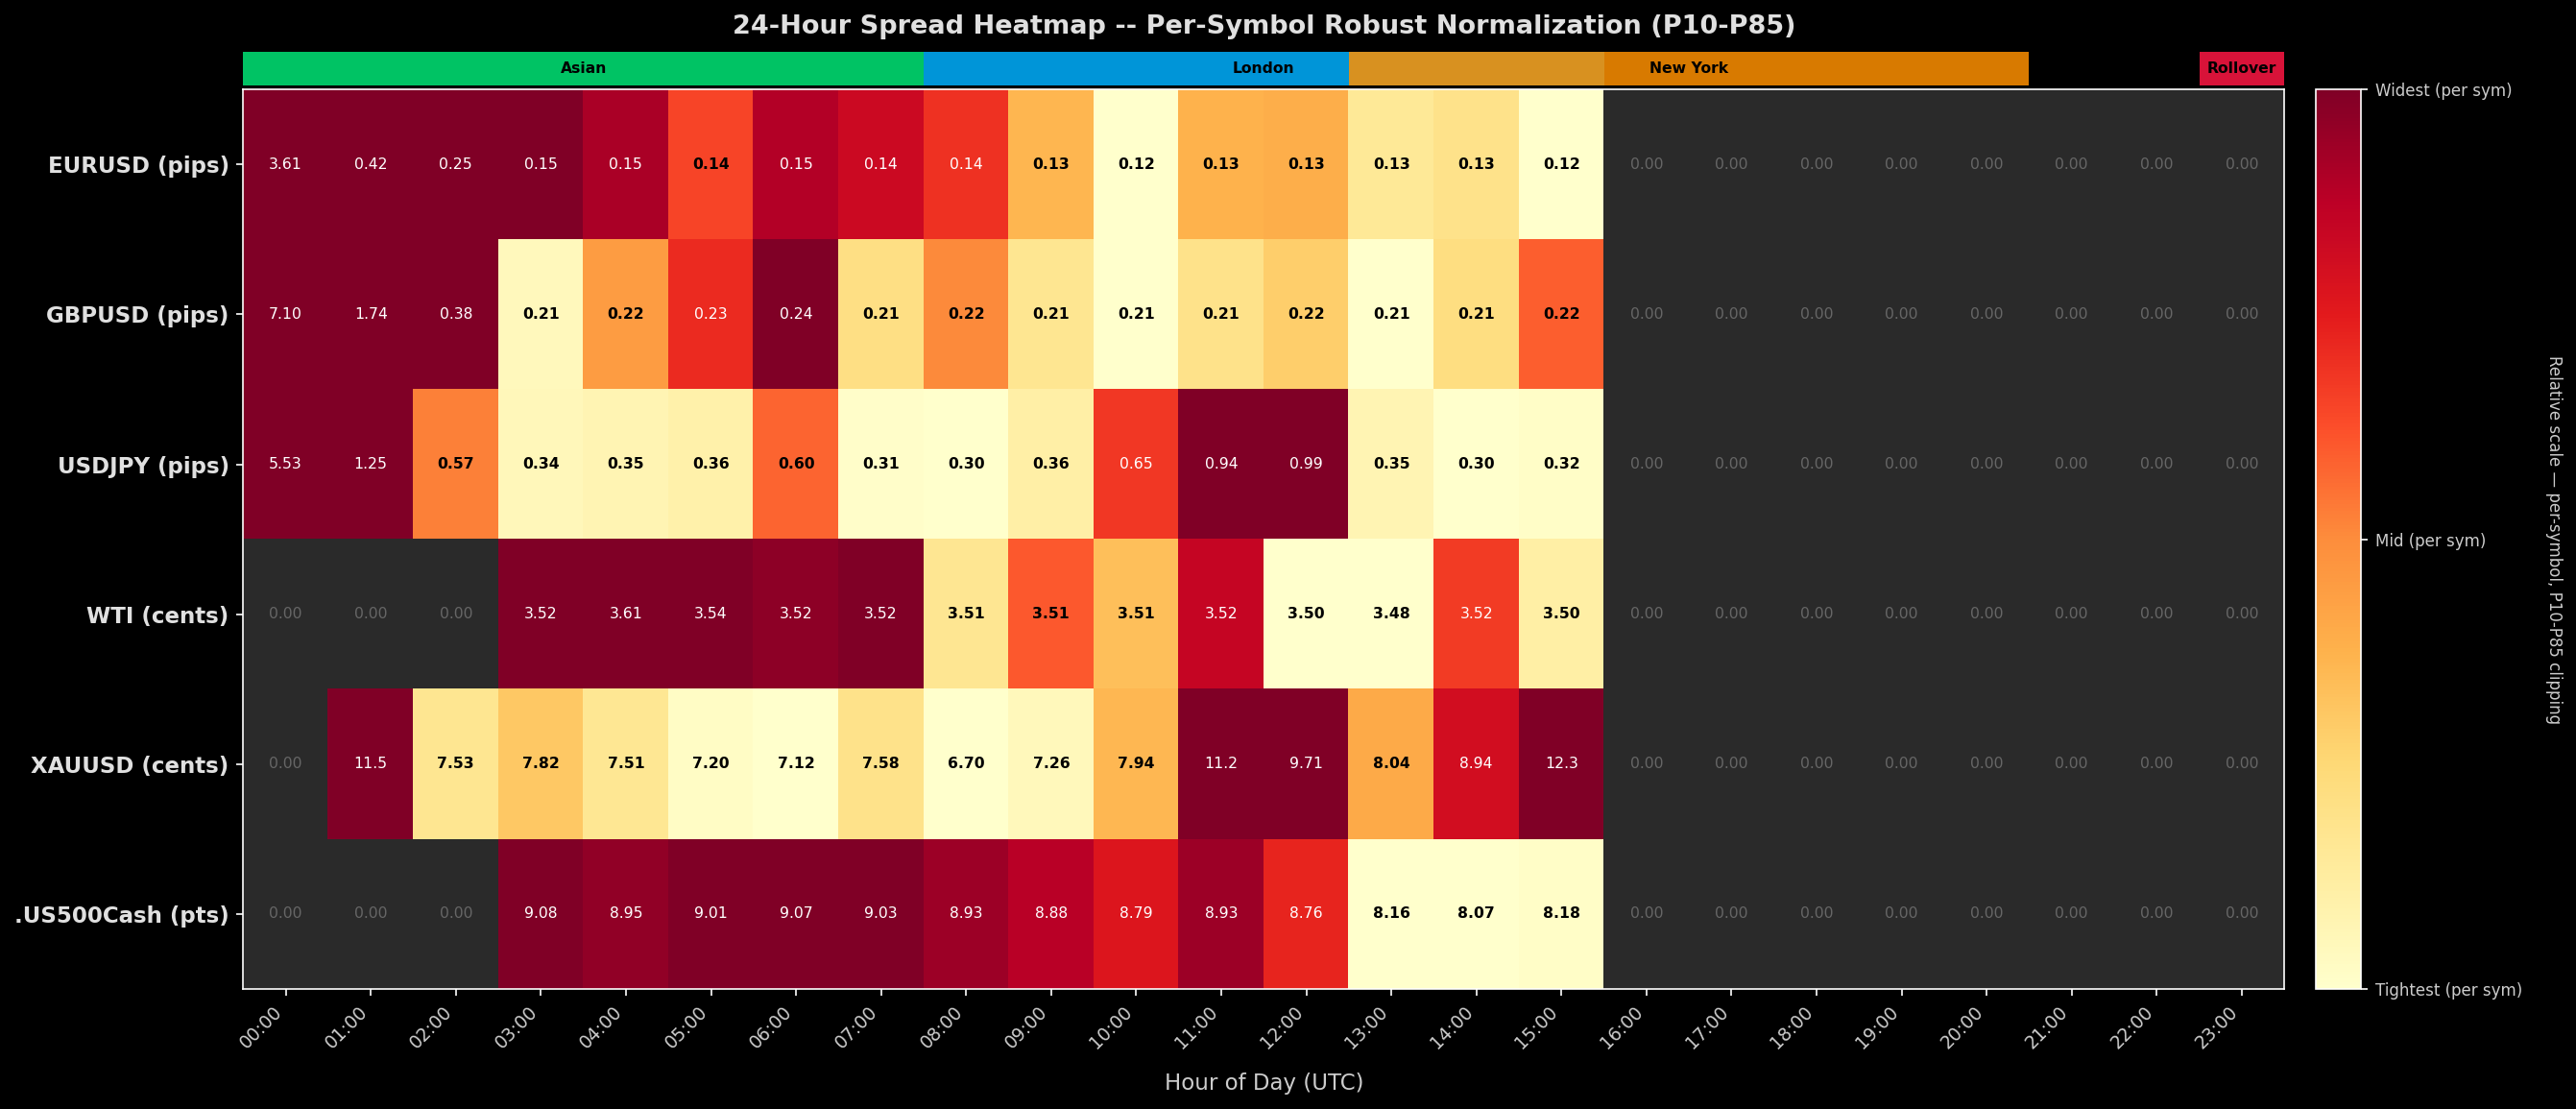

In [29]:
raw  = df_spread.T.values
norm = row_normalize_robust(raw)
syms = list(df_spread.columns)
fmt  = lambda v: f"{v:.2f}" if v < 10 else f"{v:.1f}"

draw_heatmap(
    raw, norm, syms,
    cmap_name = "YlOrRd",
    cbar_lo   = "Tightest (per sym)",
    cbar_hi   = "Widest (per sym)",
    title     = "24-Hour Spread Heatmap -- Per-Symbol Robust Normalization (P10-P85)",
    fmt_fn    = fmt,
)


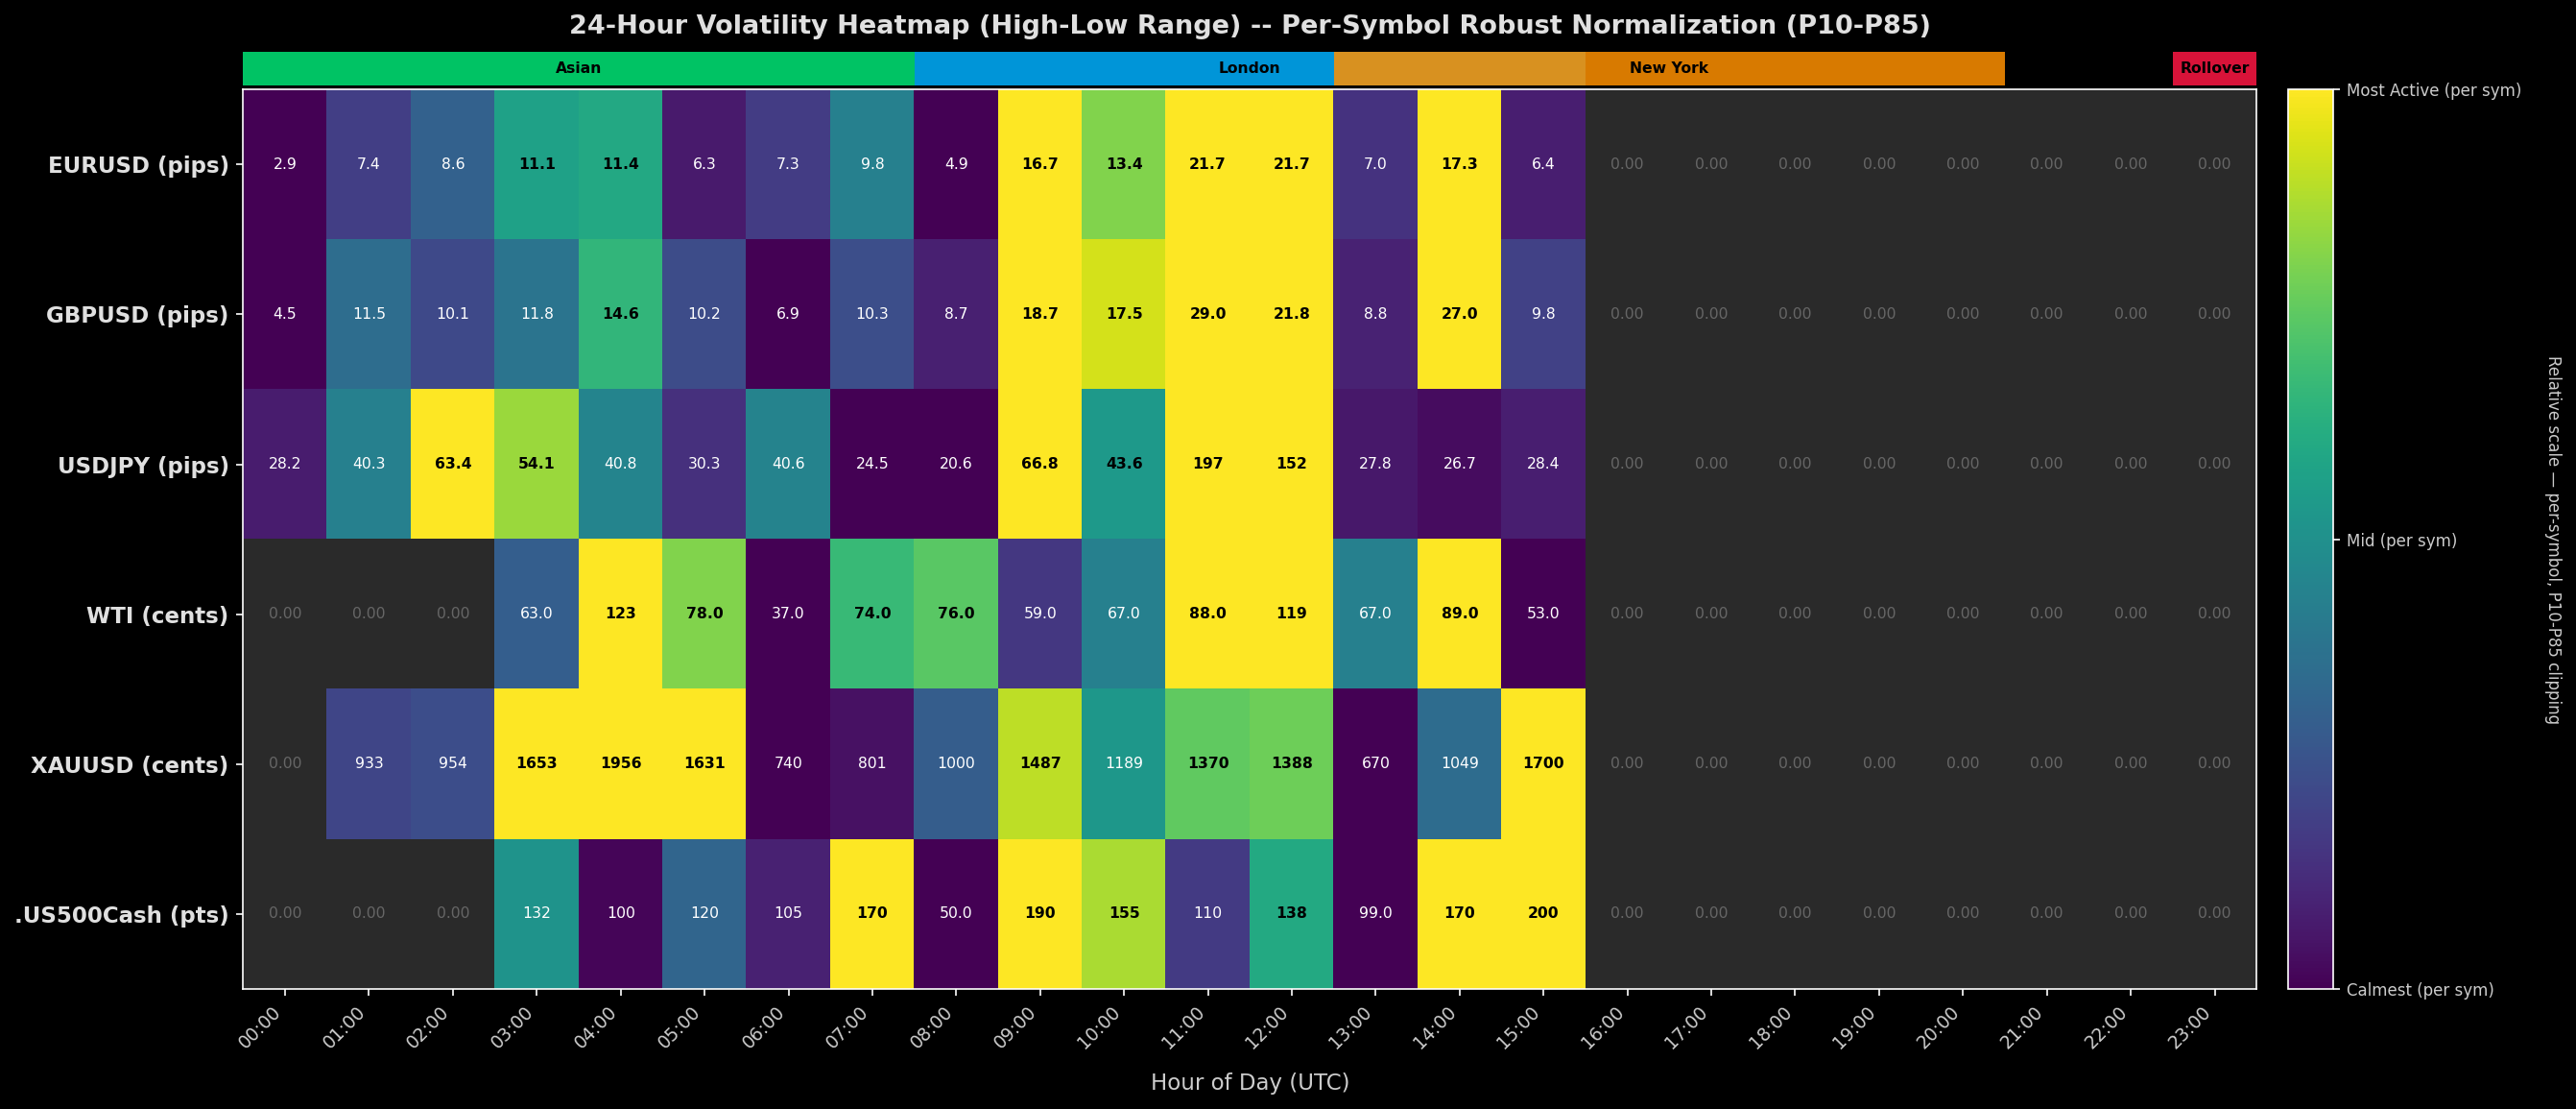

In [30]:
raw  = df_vol.T.values
norm = row_normalize_robust(raw)
syms = list(df_vol.columns)
fmt  = lambda v: f"{v:.1f}" if v < 100 else f"{v:.0f}"

draw_heatmap(
    raw, norm, syms,
    cmap_name = "viridis",
    cbar_lo   = "Calmest (per sym)",
    cbar_hi   = "Most Active (per sym)",
    title     = "24-Hour Volatility Heatmap (High-Low Range) -- Per-Symbol Robust Normalization (P10-P85)",
    fmt_fn    = fmt,
)


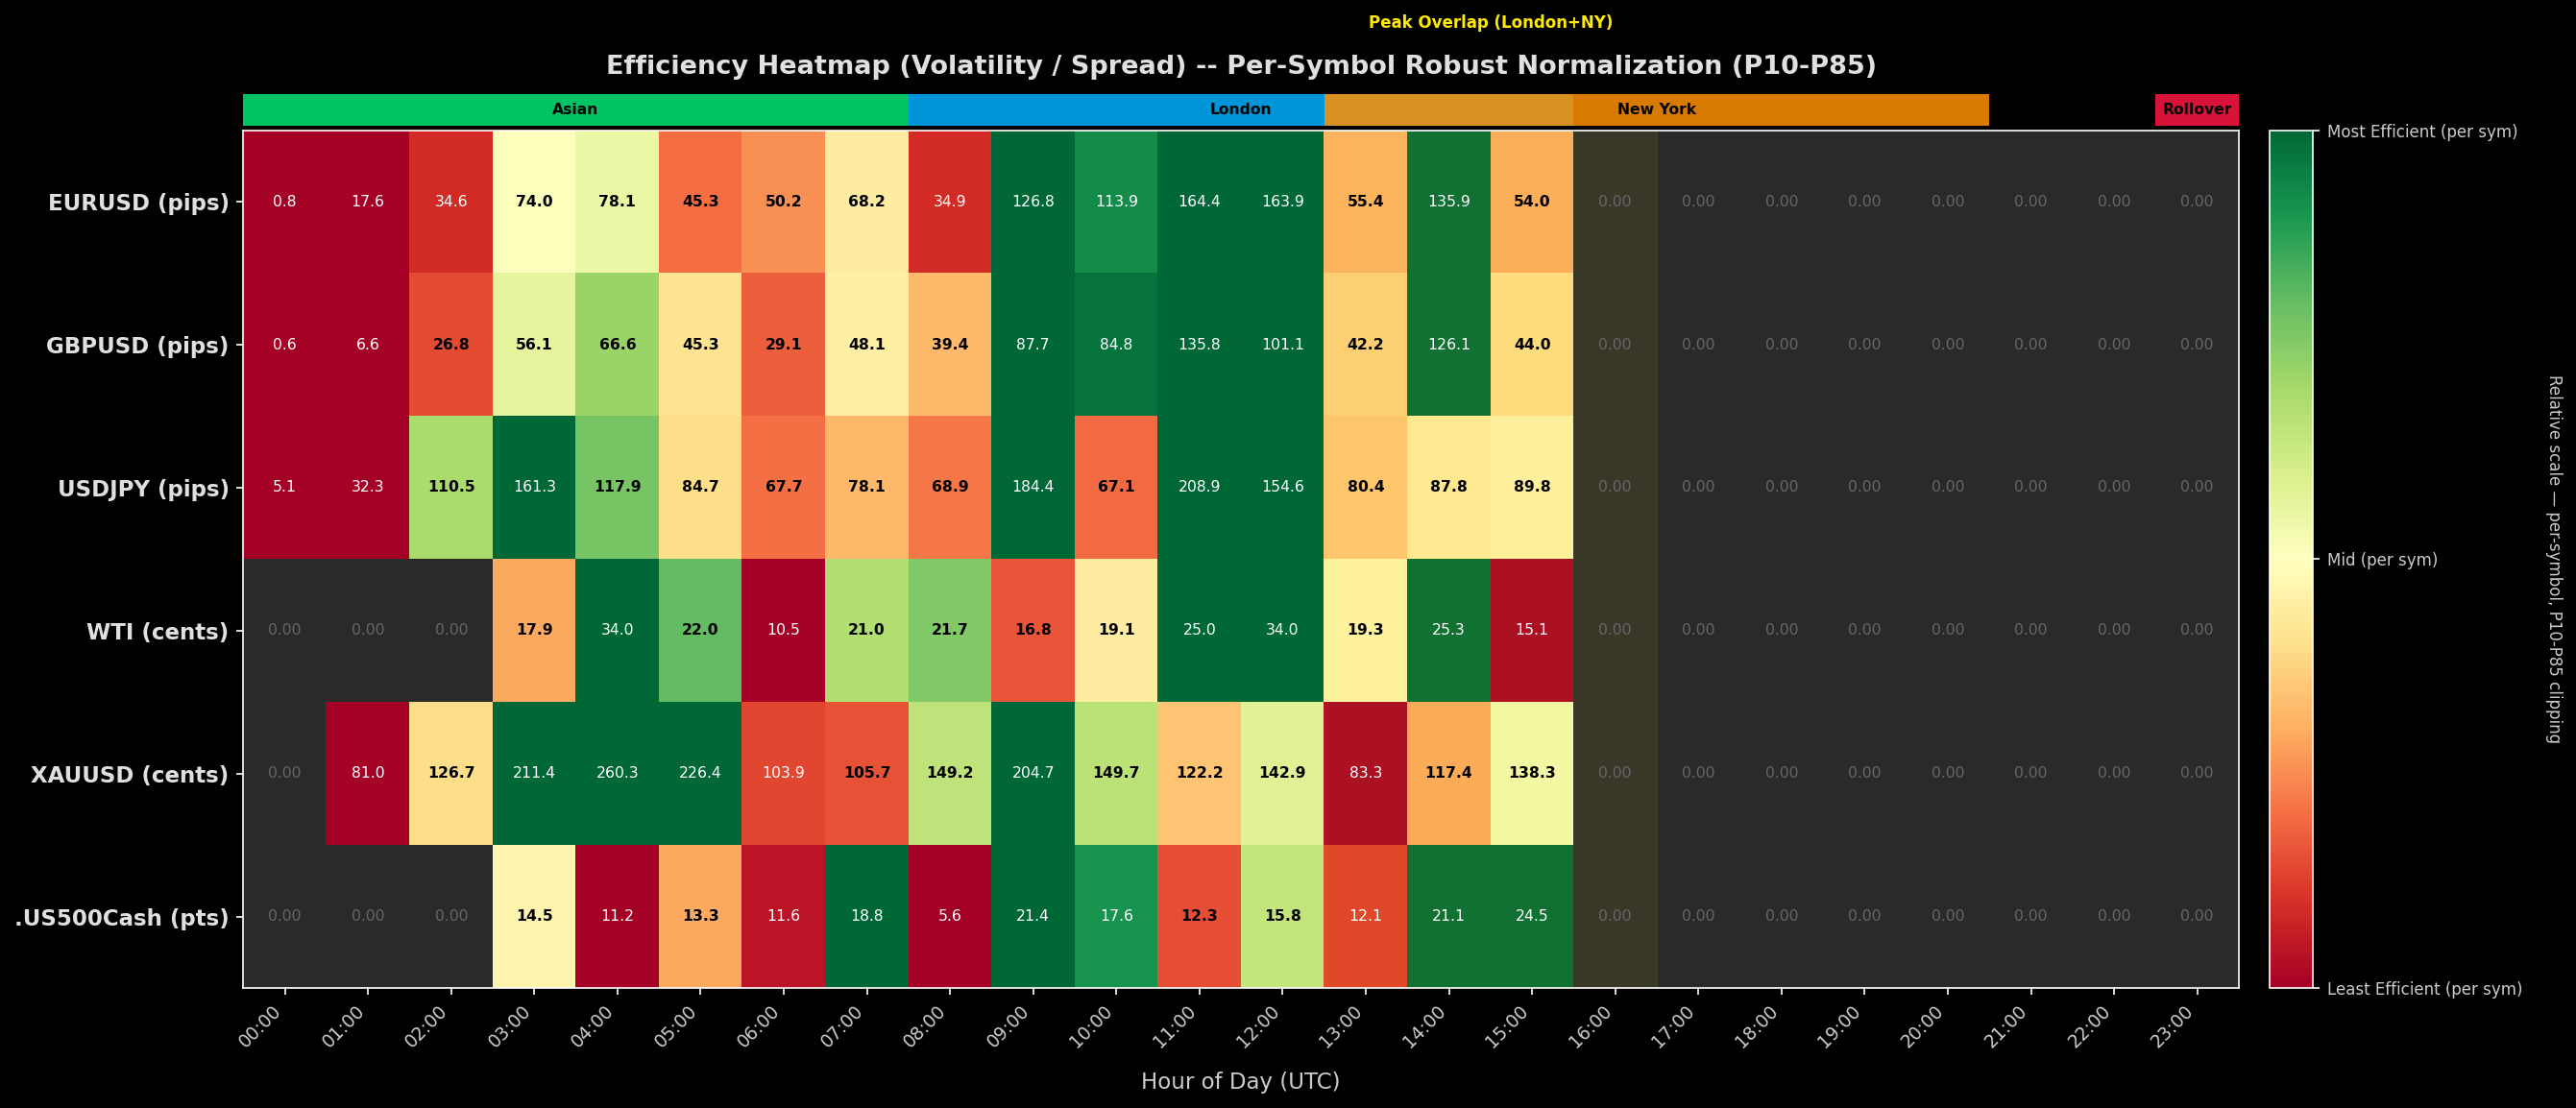

In [31]:
sp_safe = df_spread.replace(0, np.nan)
df_eff  = (df_vol / sp_safe).fillna(0)

raw  = df_eff.T.values
norm = row_normalize_robust(raw)
syms = list(df_eff.columns)
fmt  = lambda v: f"{v:.1f}" if v < 1000 else f"{v/1000:.1f}k"

draw_heatmap(
    raw, norm, syms,
    cmap_name = "RdYlGn",
    cbar_lo   = "Least Efficient (per sym)",
    cbar_hi   = "Most Efficient (per sym)",
    title     = "Efficiency Heatmap (Volatility / Spread) -- Per-Symbol Robust Normalization (P10-P85)",
    fmt_fn    = fmt,
    overlap   = True,
)


In [32]:
rows = []
for col in df_spread.columns:
    sym     = col.split(" ")[0]
    unit, _ = unit_map.get(sym, ("?", 1))
    sp      = df_spread[col]
    vol     = df_vol[col]  if col in df_vol.columns else pd.Series([0]*24)
    eff     = df_eff[col]  if col in df_eff.columns else pd.Series([0]*24)

    nz_sp  = sp[sp > 0]
    nz_eff = eff[eff > 0]

    tightest_hr = f"{int(nz_sp.idxmin()):02d}:00 UTC" if len(nz_sp) > 0 else "N/A"
    widest_hr   = f"{int(sp.idxmax()):02d}:00 UTC" if len(sp) > 0 else "N/A"
    peak_vol_hr = f"{int(vol.idxmax()):02d}:00 UTC" if len(vol) > 0 else "N/A"
    best_trade  = f"{int(nz_eff.idxmax()):02d}:00 UTC" if len(nz_eff) > 0 else "N/A"

    rows.append({
        "Symbol":          sym,
        "Unit":            unit,
        "Avg 24h Spread":  f"{sp.mean():.3f}",
        "Tightest Hr":     tightest_hr,
        "Widest Hr":       widest_hr,
        "Peak Vol Hr":     peak_vol_hr,
        "Best Trade Hr":   best_trade,
    })

df_summary = pd.DataFrame(rows)
print("=== 24-Hour Session Liquidity Summary ===")
print(df_summary.to_string(index=False))


=== 24-Hour Session Liquidity Summary ===
    Symbol  Unit Avg 24h Spread Tightest Hr Widest Hr Peak Vol Hr Best Trade Hr
    EURUSD  pips          0.251   10:00 UTC 00:00 UTC   11:00 UTC     11:00 UTC
    GBPUSD  pips          0.502   10:00 UTC 00:00 UTC   11:00 UTC     11:00 UTC
    USDJPY  pips          0.563   08:00 UTC 00:00 UTC   11:00 UTC     11:00 UTC
       WTI cents          1.907   13:00 UTC 04:00 UTC   04:00 UTC     04:00 UTC
    XAUUSD cents          5.350   08:00 UTC 15:00 UTC   04:00 UTC     04:00 UTC
.US500Cash   pts          4.744   14:00 UTC 03:00 UTC   15:00 UTC     15:00 UTC


In [33]:
mt5.shutdown()
print("MT5 connection closed.")


MT5 connection closed.


## How to Read These Heatmaps

### Visual Enhancements
- **Dark Grey Cells (#2A2A2A):** Zero or market-closed hours (e.g. weekends or quiet hours for specific instruments).
- **Dynamic Text Contrast:** Black text on bright cells (yellow/orange/light green), white text on dark cells (red/purple/dark green).
- **Robust Normalization (P10-P85):** Each row scaled independently, clipping extreme rollover spikes to keep typical trading hours readable.
